# Notebook 01 — EDA & Statistical Baseline

This notebook:
1. Visualizes the synthetic dataset and all three anomaly types
2. Tunes and evaluates the EWMA statistical detector
3. Reports precision, recall, F1, and ROC-AUC on the test split

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, precision_recall_curve
)

from src.ingestion.features import Normalizer, time_split, rolling_zscore
from src.models.statistical import EWMADetector

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 4)

## 1. Load Data

In [3]:
df = pd.read_csv('../data/sample/univariate.csv', parse_dates=['timestamp'])
print(f"Rows: {len(df):,}  |  Anomalies: {df['is_anomaly'].sum():,} ({df['is_anomaly'].mean():.2%})")
df.head()

Rows: 100,000  |  Anomalies: 1,998 (2.00%)


,timestamp,value,is_anomaly,anomaly_type
0,2024-01-01 00:00:00,0.045708,0,normal
1,2024-01-01 00:01:00,-0.155872,0,normal
2,2024-01-01 00:02:00,0.112819,0,normal
3,2024-01-01 00:03:00,0.141462,0,normal
4,2024-01-01 00:04:00,-0.292153,0,normal


## 2. Visualise the Signal & Anomaly Types

We zoom into a 500-row window that contains all three anomaly types.

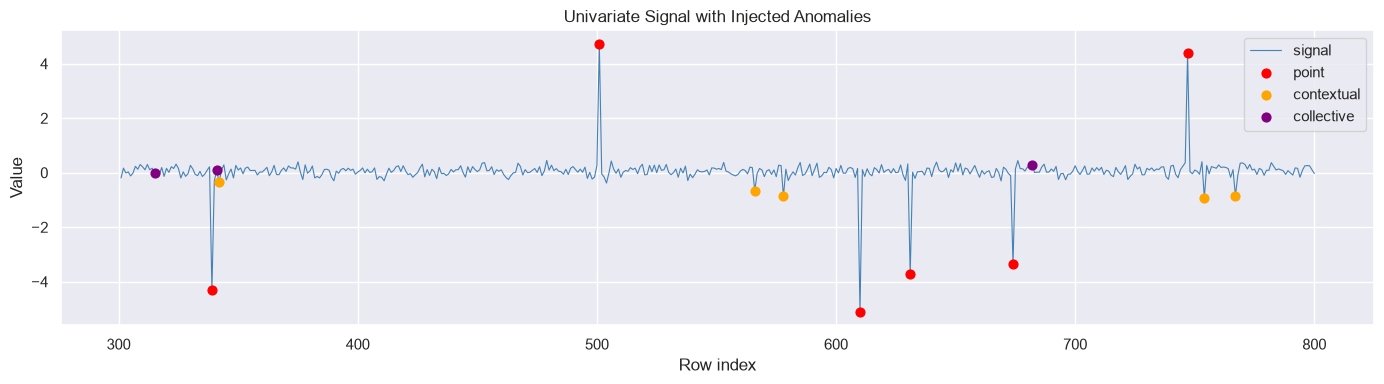

In [4]:
# Find a window that contains at least one of each type
window_df = df[df['anomaly_type'] != 'normal'].groupby('anomaly_type').first().reset_index()
center = int(df[df['anomaly_type'] != 'normal'].index[10])
view = df.iloc[max(0, center-200):center+300].copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(view.index, view['value'], color='steelblue', lw=0.8, label='signal')

colors = {'point': 'red', 'contextual': 'orange', 'collective': 'purple'}
for atype, color in colors.items():
    mask = view['anomaly_type'] == atype
    ax.scatter(view.index[mask], view.loc[mask, 'value'],
               color=color, s=40, zorder=5, label=atype)

ax.set_title('Univariate Signal with Injected Anomalies')
ax.set_xlabel('Row index')
ax.set_ylabel('Value')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Train / Val / Test Split

In [5]:
train_df, val_df, test_df = time_split(df)
print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

normalizer = Normalizer()
train_norm = normalizer.fit_transform(train_df, ['value'])
val_norm   = normalizer.transform(val_df)
test_norm  = normalizer.transform(test_df)

Train: 70,000  Val: 15,000  Test: 15,000


## 4. Rolling Z-Score (Simple Baseline)

Before the EWMA detector, let's see what a plain rolling z-score looks like.

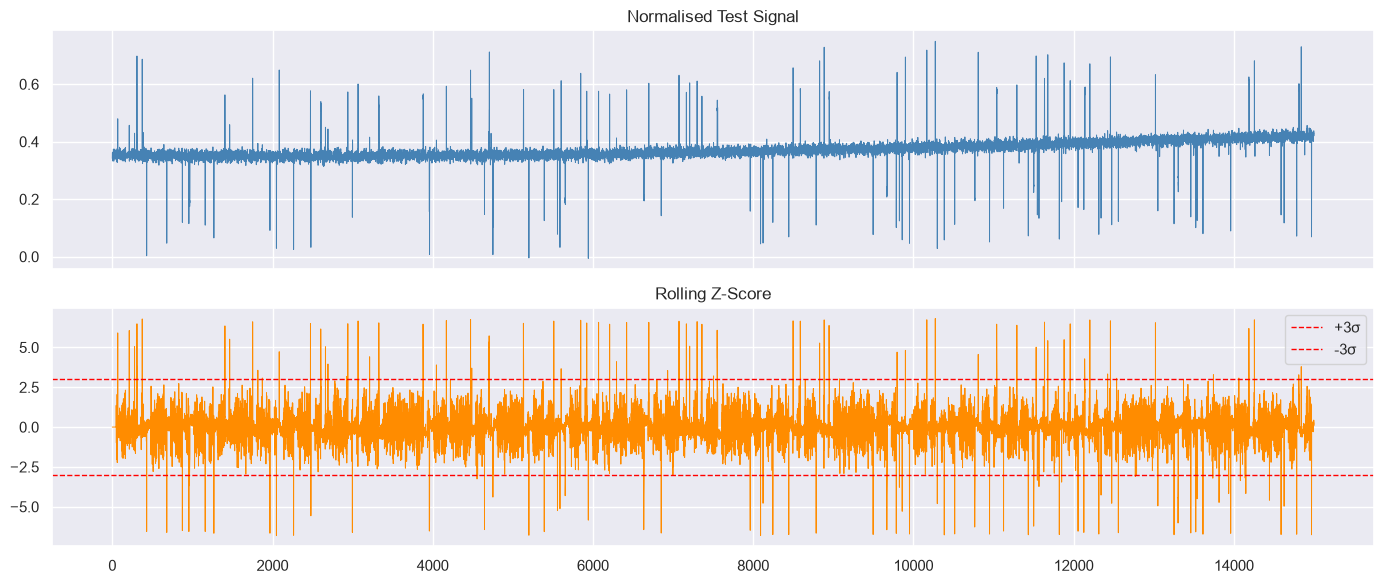

In [6]:
zscore = rolling_zscore(test_norm['value'], window=50).fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(test_norm['value'].values, lw=0.7, color='steelblue')
axes[0].set_title('Normalised Test Signal')

axes[1].plot(zscore.values, lw=0.7, color='darkorange')
axes[1].axhline(3, color='red', ls='--', lw=1, label='+3σ')
axes[1].axhline(-3, color='red', ls='--', lw=1, label='-3σ')
axes[1].set_title('Rolling Z-Score')
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. EWMA Detector — Tune & Evaluate

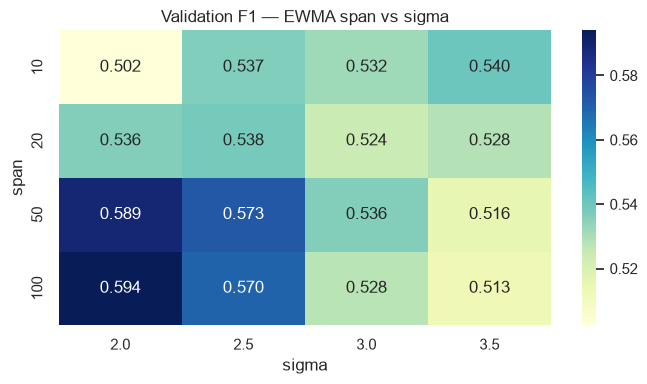

Best params: span=100, sigma=2.0  (val F1=0.5940)


In [7]:
# Grid search over span and sigma on the validation set
results = []
for span in [10, 20, 50, 100]:
    for sigma in [2.0, 2.5, 3.0, 3.5]:
        det = EWMADetector(span=span, threshold_sigma=sigma)
        det.fit(train_norm, ['value'])
        _, flags = det.predict(val_norm)
        f1 = f1_score(val_df['is_anomaly'], flags.astype(int), zero_division=0)
        results.append({'span': span, 'sigma': sigma, 'f1': f1})

results_df = pd.DataFrame(results).pivot(index='span', columns='sigma', values='f1')
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(results_df, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax)
ax.set_title('Validation F1 — EWMA span vs sigma')
plt.tight_layout()
plt.show()

best = max(results, key=lambda x: x['f1'])
print(f"Best params: span={best['span']}, sigma={best['sigma']}  (val F1={best['f1']:.4f})")

In [8]:
# Evaluate best config on test set
ewma = EWMADetector(span=best['span'], threshold_sigma=best['sigma'])
ewma.fit(train_norm, ['value'])
scores, flags = ewma.predict(test_norm)
anomaly_scores = ewma.anomaly_score(test_norm)
test_labels = test_df['is_anomaly'].values

print(f"Precision : {precision_score(test_labels, flags.astype(int), zero_division=0):.4f}")
print(f"Recall    : {recall_score(test_labels, flags.astype(int), zero_division=0):.4f}")
print(f"F1        : {f1_score(test_labels, flags.astype(int), zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(test_labels, anomaly_scores):.4f}")

Precision : 0.6211
Recall    : 0.4700
F1        : 0.5351
ROC-AUC   : 0.7894


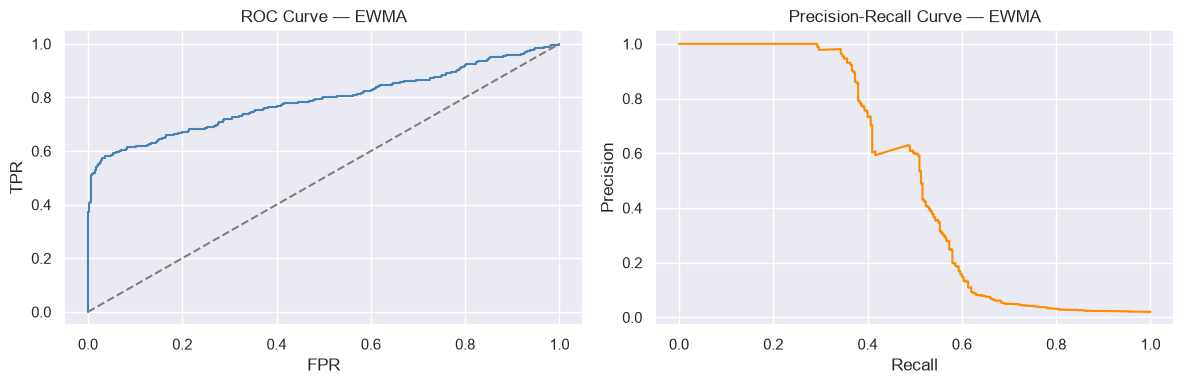

In [9]:
# ROC and Precision-Recall curves
fpr, tpr, _ = roc_curve(test_labels, anomaly_scores)
prec, rec, _ = precision_recall_curve(test_labels, anomaly_scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, color='steelblue')
axes[0].plot([0,1],[0,1],'--', color='grey')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve — EWMA')

axes[1].plot(rec, prec, color='darkorange')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — EWMA')

plt.tight_layout()
plt.show()

## 6. Anomaly Score Distribution

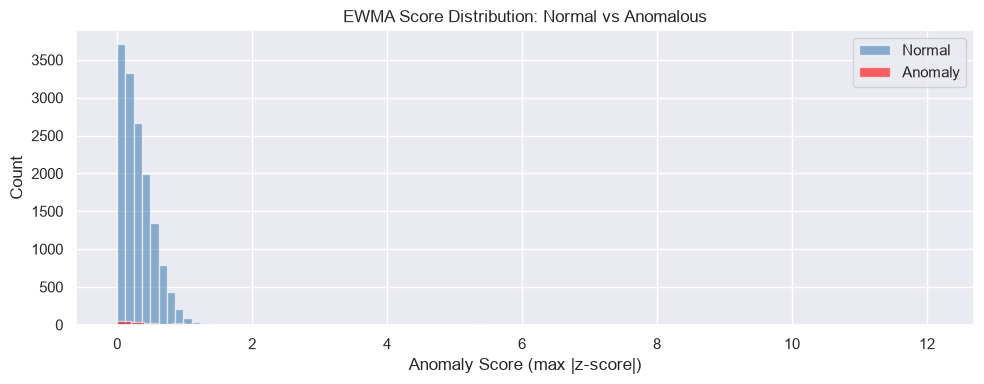

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(anomaly_scores[test_labels == 0], bins=60, alpha=0.6, label='Normal', color='steelblue')
ax.hist(anomaly_scores[test_labels == 1], bins=60, alpha=0.6, label='Anomaly', color='red')
ax.set_xlabel('Anomaly Score (max |z-score|)')
ax.set_ylabel('Count')
ax.set_title('EWMA Score Distribution: Normal vs Anomalous')
ax.legend()
plt.tight_layout()
plt.show()